In [46]:
%cd "C:\Users\asmaa\Desktop\Amr\2nd Paper\Master's Thesis v0.4"

C:\Users\asmaa\Desktop\Amr\2nd Paper\Master's Thesis v0.4


In [47]:
import models

Epoch 0, Loss: 0.206346
Epoch 500, Loss: 0.002807
Epoch 1000, Loss: 0.000874
Epoch 1500, Loss: 0.000456
Epoch 2000, Loss: 0.000341
Epoch 2500, Loss: 0.000283
Epoch 3000, Loss: 0.000438
Epoch 3500, Loss: 0.000225
Epoch 4000, Loss: 0.000177
Epoch 4500, Loss: 0.000153


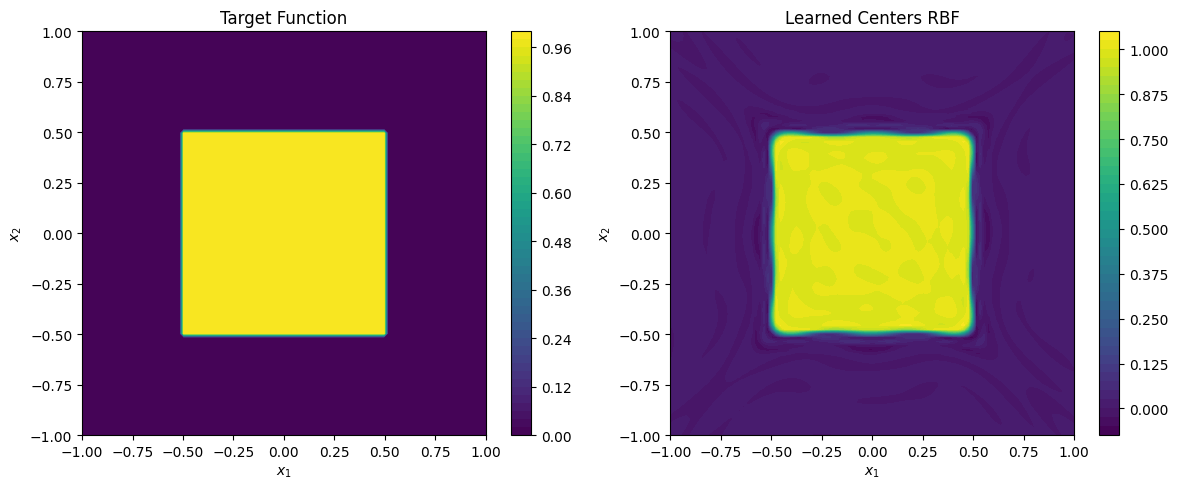

In [56]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Target function
def target_function(x1, x2):
    return 1.0 * ((np.abs(x1) < 0.5) & (np.abs(x2) < 0.5))

# Generate training data
x1 = np.linspace(-1, 1, 50)
x2 = np.linspace(-1, 1, 50)
X1, X2 = np.meshgrid(x1, x2)
Y_true = target_function(X1, X2)

x_data = np.stack([X1.ravel(), X2.ravel()], axis=1)
y_data = Y_true.ravel()

x_tensor = torch.tensor(x_data, dtype=torch.float32)
y_tensor = torch.tensor(y_data, dtype=torch.float32)

# Fixed number of basis functions
num_centers = 100  # e.g. 10x10 grid

# Fixed weights: uniform and sum to 1
weights = torch.ones(num_centers) / num_centers

# RBF sigma
sigma = 0.05

# Initialize centers as a grid, but make them trainable
init_grid = np.linspace(-1, 1, int(np.sqrt(num_centers)))
c1, c2 = np.meshgrid(init_grid, init_grid)
init_centers = np.stack([c1.ravel(), c2.ravel()], axis=1)

class LearnableCentersRBF(nn.Module):
    def __init__(self, init_centers, weights, sigma):
        super().__init__()
        # Centers are trainable parameters
        self.model = models.vanilla_network(2, 32, 1, 2, 'DRBF')
        # Fixed weights, no gradient

    def forward(self, x):
        # x: (N, 2), centers: (B, 2)
        return self.model(x).squeeze()

# Create model
model = LearnableCentersRBF(init_centers, weights, sigma)

# Optimizer only updates centers
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Training loop
num_epochs = 5000
for epoch in range(num_epochs):
    optimizer.zero_grad()
    y_pred = model(x_tensor)
    loss = torch.mean(torch.square(y_pred- y_tensor))
    loss.backward()
    optimizer.step()

    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.6f}")

# Evaluate on a test grid
x1_test, x2_test = np.meshgrid(np.linspace(-1, 1, 100), np.linspace(-1, 1, 100))
x_test = np.stack([x1_test.ravel(), x2_test.ravel()], axis=1)
x_test_tensor = torch.tensor(x_test, dtype=torch.float32)

with torch.no_grad():
    y_pred_test = model(x_test_tensor).numpy().reshape(100, 100)

Y_target = target_function(x1_test, x2_test)

# Plot results
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
c1 = axes[0].contourf(x1_test, x2_test, Y_target, levels=50, cmap='viridis')
axes[0].set_title('Target Function')
axes[0].set_xlabel('$x_1$'); axes[0].set_ylabel('$x_2$')
fig.colorbar(c1, ax=axes[0])

c2 = axes[1].contourf(x1_test, x2_test, y_pred_test, levels=50, cmap='viridis')
axes[1].set_title('Learned Centers RBF')
axes[1].set_xlabel('$x_1$'); axes[1].set_ylabel('$x_2$')
fig.colorbar(c2, ax=axes[1])

plt.tight_layout()
plt.show()


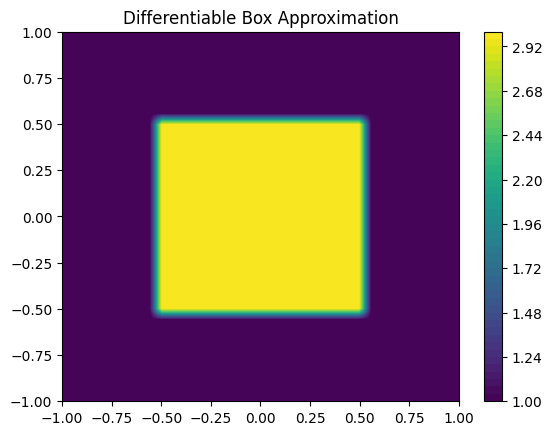

In [72]:
import torch
import matplotlib.pyplot as plt

def box_approx_2d(x, y, domain, box, eps):
    # domain = (x_min, x_max, y_min, y_max)
    # box = (x_left, x_right, y_bottom, y_top)
    def ramp(v, L, R, e):
        return torch.clamp(torch.min((v - (L - e)) / e, ((R + e) - v) / e), 0, 1)
    
    sx = ramp(x, box[0], box[1], eps)
    sy = ramp(y, box[2], box[3], eps)
    return (v_max - v_min)*(sx * sy) + v_min

# Parameters
domain = (-1, 1, -1, 1)
box = (-0.5, 0.5, -0.5, 0.5)  # (x_left, x_right, y_bottom, y_top)
eps = 0.05
v_max = 3
v_min = 1
# Generate grid
x = torch.linspace(domain[0], domain[1], 100)
y = torch.linspace(domain[2], domain[3], 100)
X, Y = torch.meshgrid(x, y, indexing='ij')

Z = box_approx_2d(X, Y, domain, box, eps)

plt.contourf(X.numpy(), Y.numpy(), Z.numpy(), levels=50, cmap='viridis')
plt.colorbar()
plt.title('Differentiable Box Approximation')
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Grid
x = np.linspace(-2, 2, 1000)
dx = x[1] - x[0]

# Permittivity profile with a vertical interface at x=0
epsilon = np.where(x < 0, 2.0, 5.0)

# Electric field (smooth function)
E_x = np.sin(np.pi * x)

# First derivative of epsilon (finite differences)
d_epsilon_dx = np.gradient(epsilon, dx)

# Compute the term inside the outer derivative: (1/ε) * (dε/dx) * E_x
inner_term = (1 / epsilon) * d_epsilon_dx * E_x

# Compute the full expression: d/dx [ (1/ε) * dε/dx * E_x ]
result = np.gradient(inner_term, dx)

# Plotting
plt.figure(figsize=(10, 12))

plt.subplot(3, 1, 1)
plt.plot(x, epsilon, label='ε(x)', color='orange')
plt.title("Permittivity Profile")
plt.ylabel('ε(x)')
plt.grid()

plt.subplot(3, 1, 2)
plt.plot(x, E_x, label='Eₓ(x)', color='blue')
plt.title("Electric Field Profile")
plt.ylabel('Eₓ(x)')
plt.grid()

plt.subplot(3, 1, 3)
plt.plot(x, result, label=r"$\frac{d}{dx}\left(\frac{1}{\epsilon} \frac{d\epsilon}{dx} E_x\right)$", color='red')
plt.title("Evaluated Expression")
plt.xlabel('x')
plt.ylabel('Value')
plt.grid()

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Grid
x = np.linspace(-2, 2, 10000)
y = np.linspace(-2, 2, 10000)
dx = x[1] - x[0]
dy = y[1] - y[0]
X, Y = np.meshgrid(x, y, indexing='ij')

# Define epsilon with a step at x=0 and a linear ramp in y
epsilon = np.where((np.abs(X) < 1) & (np.abs(Y) < 1), 5, 2)  # varies in y, jumps in x

# Smooth E_y (e.g., 2D Gaussian)
# Permittivities
# eps_minus = 2.0
# eps_plus = 5.0
# 
# Define permittivity ε(y)
eps_center = 5.0       # for -1 ≤ y ≤ 1
eps_outside = 2.0      # for y < -1 or y > 1
# epsilon = np.where(np.abs(Y) <= 1, eps_center, eps_outside)

# Base smooth function g(x, y)
g = np.exp(-X**2 - Y**2)

# Scaling factor α(y)
alpha = np.where(np.abs(Y) <= 1, 1.0, eps_center / eps_outside)

# Construct E(x, y) with value discontinuity but continuous εE
E_y = alpha * g
# ∂ε/∂y
d_epsilon_dy = np.gradient(epsilon, dy, axis=1)

# Inner term: (1/ε) * (∂ε/∂y) * E_y
inner_term = (1 / epsilon) * d_epsilon_dy * E_y

# Final derivative: ∂/∂x of the inner term
result = np.gradient(inner_term, dx, axis=0)
result[result > 1] = 100
result[result < -1] = -100
print(len(result[result<-1]))
print(len(result[result>1]))

# Visualization
plt.figure(figsize=(20, 8))

m=5
plt.subplot(1, 3, 1)
plt.contourf(X[::m, ::m], Y[::m, ::m], epsilon[::m, ::m], levels=50, cmap='viridis')
plt.title('Permittivity ε(x, y)')
plt.colorbar()

plt.subplot(1, 3, 2)
plt.contourf(X[::m, ::m], Y[::m, ::m], E_y[::m, ::m], levels=50, cmap='plasma')
plt.title('Electric Field E_y(x, y)')
plt.colorbar()
# 
plt.subplot(1, 3, 3)
plt.contourf(X[::m, ::m], Y[::m, ::m], result[::m, ::m], levels=50, cmap='jet')
plt.title(r"$\frac{\partial}{\partial x} \left( \frac{1}{\epsilon} \frac{\partial \epsilon}{\partial y} E_y \right)$")
plt.colorbar()

plt.tight_layout()
plt.show()


In [ ]:
3/5

In [ ]:
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt

# Physical parameters
lambda0 = 1.55  # wavelength in microns
k0 = 2 * np.pi / lambda0

# Grid parameters
nx, ny = 100, 100  # grid points in x and y
dx, dy = 0.02, 0.02  # grid spacing in microns

# Create 2D meshgrid (for visualization and permittivity)
x = (np.arange(nx) - nx//2) * dx
y = (np.arange(ny) - ny//2) * dy
X, Y = np.meshgrid(x, y, indexing='ij')

# Define permittivity profile (example: rectangular waveguide core)
eps_clad = 2.25  # cladding epsilon (n=1.5^2)
eps_core = 3.4**2  # core epsilon (n=3.4^2)
core_width = 1.0  # microns
core_height = 0.5  # microns

eps = np.ones((nx, ny)) * eps_clad
core_region = (np.abs(X) < core_width/2) & (np.abs(Y) < core_height/2)
eps[core_region] = eps_core

plt.figure()
plt.title("Permittivity profile")
plt.imshow(eps.T, origin='lower', extent=[x[0], x[-1], y[0], y[-1]], cmap='viridis')
plt.colorbar(label='ε')
plt.xlabel('x (μm)')
plt.ylabel('y (μm)')
plt.show()


def derivative_1d(n, d):
    """
    Create 1D first derivative operator matrix with central difference.
    Size: n x n, spacing d.
    Dirichlet BC assumed: derivative at boundaries handled by one-sided differences.
    """
    e = np.ones(n)
    # Central difference: (f_{i+1} - f_{i-1})/(2d)
    data = np.array([-0.5*e, 0.5*e])
    offsets = np.array([-1, 1])
    D = sp.diags(data, offsets, shape=(n, n))
    
    # Forward difference at first point
    D = D.tolil()
    D[0, 0] = -1/d
    D[0, 1] = 1/d
    
    # Backward difference at last point
    D[-1, -2] = -1/d
    D[-1, -1] = 1/d
    
    return D.tocsc()

# Derivative in x direction for entire grid
Dx_1d = derivative_1d(nx, dx)
# Derivative in y direction for entire grid
Dy_1d = derivative_1d(ny, dy)

# 2D derivative operators using Kronecker products
Ix = sp.eye(nx)
Iy = sp.eye(ny)

# ∂/∂x operator on flattened 2D grid: acts on (x,y) array flattened column-wise
Dx = sp.kron(Iy, Dx_1d)  # size (nx*ny) x (nx*ny)

# ∂/∂y operator on flattened 2D grid:
Dy = sp.kron(Dy_1d, Ix)  # size (nx*ny) x (nx*ny)

N = nx * ny

eps_flat = eps.flatten()
inv_eps_flat = 1 / eps_flat

# Diagonal matrices
Eps = sp.diags(eps_flat)
InvEps = sp.diags(inv_eps_flat)

# Build second derivatives with epsilon weighting: ∂x(1/ε ∂x E), etc.

def weighted_second_derivative(D, InvEps):
    # D: first derivative operator (Dx or Dy)
    # InvEps: diagonal matrix of 1/ε
    # Approximate ∂(1/ε ∂f/∂x) = D * InvEps * D
    return D @ InvEps @ D

# Build blocks:

Lxx = weighted_second_derivative(Dx, InvEps)
Lyy = weighted_second_derivative(Dy, InvEps)
Lxy = Dx @ InvEps @ Dy
Lyx = Dy @ InvEps @ Dx

# Assemble full operator matrix A (2N x 2N)
# Blocks:
# [Lxx + k0^2 * Eps,   Lxy]
# [Lyx,                Lyy + k0^2 * Eps]

top_left = Lxx + k0**2 * Eps
top_right = Lxy
bottom_left = Lyx
bottom_right = Lyy + k0**2 * Eps

A_top = sp.hstack([top_left, top_right])
A_bottom = sp.hstack([bottom_left, bottom_right])
A = sp.vstack([A_top, A_bottom]).tocsc()

# Solve for a few eigenvalues near k0^2 * n_core^2 (estimate)
nev = 4  # number of modes to find

# Use shift-invert mode for better convergence around target sigma
n_core = np.sqrt(eps_core)
sigma = (k0 * n_core)**2

# Solve sparse eigenvalue problem: A E = beta^2 E
vals, vecs = spla.eigs(A, k=nev, sigma=sigma, which='LM')

# Sort eigenvalues and compute effective indices
idx = np.argsort(vals.real)
beta2 = vals.real[idx]
neff = np.sqrt(beta2) / k0

print("Effective indices of modes:")
for i, n_eff in enumerate(neff):
    print(f"Mode {i+1}: neff = {n_eff:.6f}")

# Visualize first mode fields Ex and Ey
E_mode = vecs[:, idx[0]]

Ex = E_mode[:N].reshape((nx, ny))
Ey = E_mode[N:].reshape((nx, ny))

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.title("E_x field (mode 1)")
plt.imshow(np.real(Ex.T), origin='lower', extent=[x[0], x[-1], y[0], y[-1]], cmap='RdBu')
plt.colorbar()

plt.subplot(1,2,2)
plt.title("E_y field (mode 1)")
plt.imshow(np.real(Ey.T), origin='lower', extent=[x[0], x[-1], y[0], y[-1]], cmap='RdBu')
plt.colorbar()

plt.show()


Effective indices:
Mode 1: 1.659219
Mode 2: 1.653999
Mode 3: 1.627920
Mode 4: 1.625797
Mode 5: 1.578145
Mode 6: 1.575428


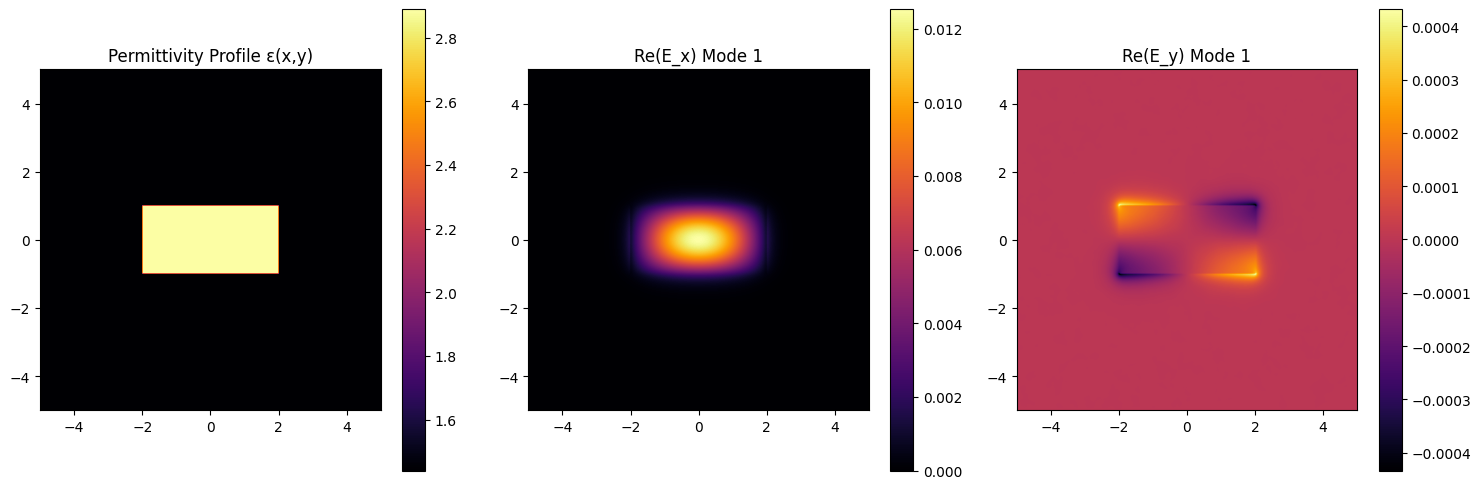

In [1]:
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt

wavelength = 1.55  # um
k0 = 2 * np.pi / wavelength

nx, ny = 500, 500
Lx, Ly = 10.0, 10.0

x = np.linspace(-Lx/2, Lx/2, nx)
y = np.linspace(-Ly/2, Ly/2, ny)
dx = x[1] - x[0]
dy = y[1] - y[0]

X, Y = np.meshgrid(x, y, indexing='ij')

eps_core = 1.7**2
eps_clad = 1.2**2
eps = np.where((np.abs(X) <= 2) & (np.abs(Y) <= 1), eps_core, eps_clad)
N = nx * ny
eps_flat = eps.flatten()

Eps = sp.diags(eps_flat)
I = sp.eye(N)

def d2_1d(n, d):
    main_diag = -2 * np.ones(n)
    off_diag = np.ones(n-1)
    return sp.diags([off_diag, main_diag, off_diag], offsets=[-1,0,1]) / d**2

D2x = d2_1d(nx, dx)
D2y = d2_1d(ny, dy)

Lx_op = sp.kron(D2x, sp.eye(ny))
Ly_op = sp.kron(sp.eye(nx), D2y)
Laplacian = Lx_op + Ly_op

def d1_1d(n, d):
    off_diag_p = np.ones(n-1)
    off_diag_m = -np.ones(n-1)
    return sp.diags([off_diag_m, np.zeros(n), off_diag_p], offsets=[-1,0,1]) / (2*d)

Dx_1d = d1_1d(nx, dx)
Dy_1d = d1_1d(ny, dy)

Dx = sp.kron(Dx_1d, sp.eye(ny))
Dy = sp.kron(sp.eye(nx), Dy_1d)

eps_x = Dx @ eps_flat
eps_y = Dy @ eps_flat

Eps_x = sp.diags(eps_x)
Eps_y = sp.diags(eps_y)

eps_inv_flat = 1.0 / eps_flat
Eps_inv = sp.diags(eps_inv_flat)

# Coupling off-diagonal terms
Term1 = Eps_inv @ Eps_y @ Dx
Term2 = Eps_inv @ Eps_x @ Dy
A12 = -(Term1 + Term2)
A21 = -A12.transpose()

# Self-polarization terms
A11_self = Dx @ (Eps_inv @ Eps_x)
A22_self = Dy @ (Eps_inv @ Eps_y)

# Diagonal blocks including all terms
A11 = Laplacian + k0**2 * Eps + A11_self
A22 = Laplacian + k0**2 * Eps + A22_self

top = sp.hstack([A11, A12])
bottom = sp.hstack([A21, A22])
A = sp.vstack([top, bottom]).tocsc()

nev = 6
sigma = (k0**2) * eps_core - 0.1

vals, vecs = spla.eigsh(A, k=nev, sigma=sigma, which='LM')

idx = np.argsort(vals.real)[::-1]
beta2 = vals.real[idx]
neff = np.sqrt(beta2) / k0

print("Effective indices:")
for i, n_eff in enumerate(neff):
    print(f"Mode {i+1}: {n_eff:.6f}")

E_mode = vecs[:, idx[0]]
Ex = E_mode[:N].reshape((nx, ny))
Ey = E_mode[N:].reshape((nx, ny))

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.title("Permittivity Profile ε(x,y)")
plt.imshow(eps.T, origin='lower', extent=[x[0], x[-1], y[0], y[-1]], cmap='inferno')
plt.colorbar()

plt.subplot(1,3,2)
plt.title("Re(E_x) Mode 1")
plt.imshow(np.real(Ex.T), origin='lower', extent=[x[0], x[-1], y[0], y[-1]], cmap='inferno')
plt.colorbar()

plt.subplot(1,3,3)
plt.title("Re(E_y) Mode 1")
plt.imshow(np.real(Ey.T), origin='lower', extent=[x[0], x[-1], y[0], y[-1]], cmap='inferno')
plt.colorbar()

plt.tight_layout()
plt.show()


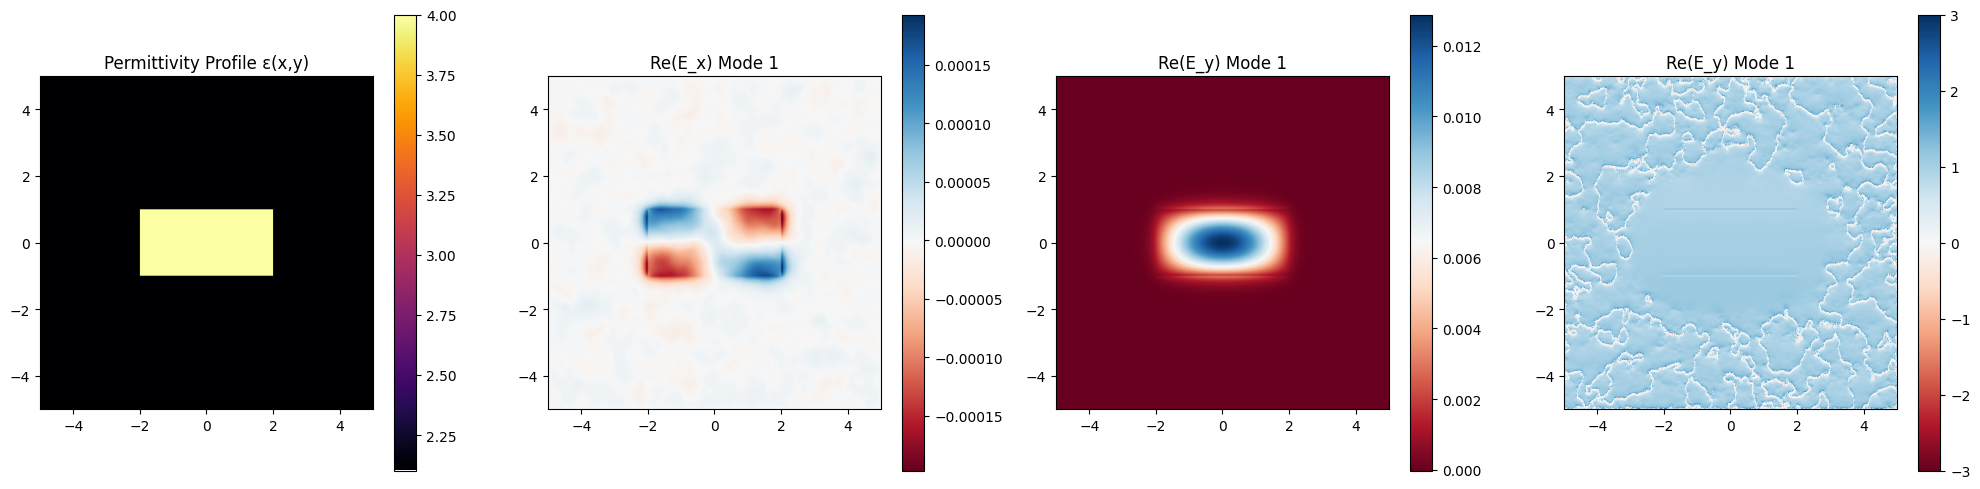

In [4]:

E_mode = vecs[:, idx[1]]
Ex = E_mode[:N].reshape((nx, ny))
Ey = E_mode[N:].reshape((nx, ny))

plt.figure(figsize=(20,5))

plt.subplot(1,4,1)
plt.title("Permittivity Profile ε(x,y)")
plt.imshow(eps.T, origin='lower', extent=[x[0], x[-1], y[0], y[-1]], cmap='inferno')
plt.colorbar()

plt.subplot(1,4,2)
plt.title("Re(E_x) Mode 1")
plt.imshow(np.real(Ex.T), origin='lower', extent=[x[0], x[-1], y[0], y[-1]], cmap='RdBu')
plt.colorbar()

plt.subplot(1,4,3)
plt.title("Re(E_y) Mode 1")
plt.imshow(np.real(Ey.T), origin='lower', extent=[x[0], x[-1], y[0], y[-1]], cmap='RdBu')
plt.colorbar()

# plt.subplot(1,4,4)
# plt.title("Re(E_y) Mode 1")
# dividend = np.copy(Ex.T)
# dividend[np.abs(dividend)< 1e-1 * np.max(np.abs(dividend))] = -1
# plt.imshow(((Ex.T[1:, :])/(dividend[:-1, :])), origin='lower', extent=[x[0], x[-1], y[0], y[-1]], cmap='RdBu')
# plt.colorbar()
plt.subplot(1,4,4)
plt.title("Re(E_y) Mode 1")
division_results = Ey.T[1:, :] / Ey.T[:-1, :]
# division_results = Ex.T[:, 1:] / Ex.T[:, :-1]
division_results[np.abs(division_results) > 2] = 0
# division_results = Ey.T[:, 1:]/1e7 / Ex.T[:, :-1]
# division_results[np.abs(division_results) > 1e1] = 1
plt.imshow((division_results), origin='lower', extent=[x[0], x[-1], y[0], y[-1]], cmap='RdBu')
plt.clim(-3,3)
plt.colorbar()


plt.tight_layout()
plt.show()

2.006944444444444